 # Data imports 
The dataset were collected by EmmaTools device on a 5-axes machine-tool of Five Machining in an aeronautic company that manufactures structural parts in aluminum alloy. The matrix consists in 72 variables (columns), measured every tenth of a second (rows), during one day of industrial production.

In [ ]:
# Import of the needed libraires
#graphical librairies
import matplotlib.pyplot as plt
import seaborn as sns

#data librairies 

import pandas as pd
import numpy as np

from pandas.plotting import scatter_matrix


In [4]:
#data importand creation of panda object
data_panda = pd.read_csv('dataset7.csv')

Check that import went well. 
Display the columns names

In [5]:
print(data_panda.keys())
#print(data_panda)

Index(['timeTotal', 'timeSpindle', 'date', 'idProgP', 'idProgC', 'modeCN',
       'idTool', 'InstTool', 'ToolWear', 'Nline', 'Nbloc', 'Abloc', 'Cbloc',
       'Temp_1', 'Temp_2', 'Temp_3', 'Temp_4', 'Arms_1', 'Arms_2', 'Arms_3',
       'Arms_4', 'Apic_1', 'Apic_2', 'Apic_3', 'Apic_4', 'Vrms_1', 'Vrms_2',
       'Vrms_3', 'Vrms_4', 'Vpic_1', 'Vpic_2', 'Vpic_3', 'Vpic_4', 'PosX',
       'PosY', 'PosZ', 'PosA', 'PosC', 'SpeedX', 'SpeedY', 'SpeedZ', 'SpeedA',
       'SpeedC', 'Vf ', 'N', 'P', '%Vf', '%N', 'FFT_1', 'FFT_2', 'FFT_3',
       'FFT_4', 'FFT_5', 'FFT_6', 'FFT_7', 'FFT_8', 'FFT_9', 'FFT_10',
       'FFT_11', 'FFT_12', 'FFT_13', 'FFT_14', 'FFT_15', 'FFT_16', 'FFT_17',
       'FFT_18', 'FFT_19', 'FFT_20', 'FFT_21', 'FFT_22', 'FFT_23', 'FFT_24'],
      dtype='object')


In [6]:
nb_specimen=len(data_panda)
print('There are '+ str(nb_specimen)+' records in the set')

There are 862574 records in the set


# Objective 1: number of parts machined

## Visualization
Visualization enables to better understand the data and to verify the need of pre-treatments.
Here we use scatter plot and we focus on programm 32.


In [7]:
dp_32 = data_panda[data_panda['idProgP'] == 32]
nb_specimen=len(dp_32 )
print('There are '+ str(nb_specimen)+' records in this subset set')

There are 209585 records in this subset set


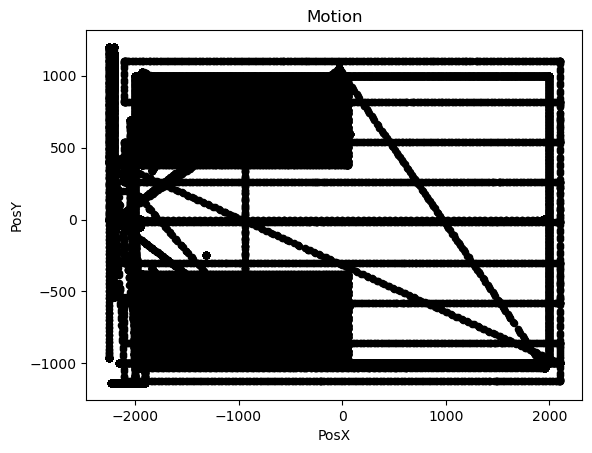

In [9]:
# Motion
dp_32.plot(kind="scatter", x='PosX', y='PosY',color='k')
plt.title('Motion') 
plt.show()


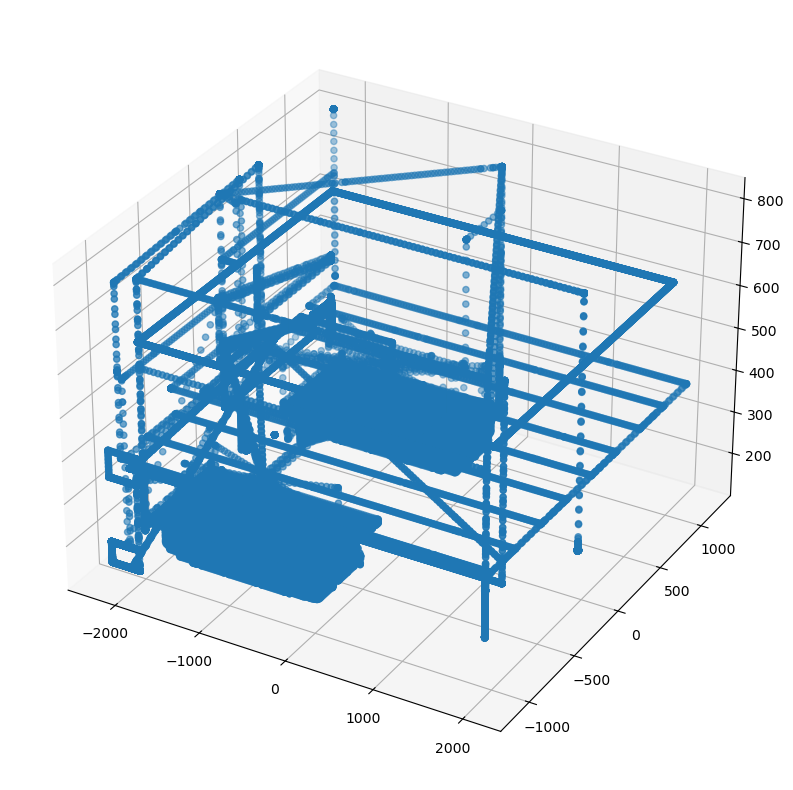

In [8]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d')
ax.scatter3D(dp_32['PosX'], dp_32['PosY'], dp_32['PosZ'])
plt.show()

In [10]:
# to facilitate futur use, we can create a set with the input columns
Input_cols = ['PosX', 'PosY']

## KMeans

### Normalisation


To garanty that the use of Euclidan distances will not favor one of the characteristics, we need to work on normalized data.

In [11]:
import copy
Norm_32 = dp_32.reset_index()
print(Norm_32.keys())
#normalisation
Norm_32[Input_cols]=(Norm_32[Input_cols]-Norm_32[Input_cols].min())/(Norm_32[Input_cols].max()-Norm_32[Input_cols].min())
#print(Norm_32[Input_cols])

Index(['index', 'timeTotal', 'timeSpindle', 'date', 'idProgP', 'idProgC',
       'modeCN', 'idTool', 'InstTool', 'ToolWear', 'Nline', 'Nbloc', 'Abloc',
       'Cbloc', 'Temp_1', 'Temp_2', 'Temp_3', 'Temp_4', 'Arms_1', 'Arms_2',
       'Arms_3', 'Arms_4', 'Apic_1', 'Apic_2', 'Apic_3', 'Apic_4', 'Vrms_1',
       'Vrms_2', 'Vrms_3', 'Vrms_4', 'Vpic_1', 'Vpic_2', 'Vpic_3', 'Vpic_4',
       'PosX', 'PosY', 'PosZ', 'PosA', 'PosC', 'SpeedX', 'SpeedY', 'SpeedZ',
       'SpeedA', 'SpeedC', 'Vf ', 'N', 'P', '%Vf', '%N', 'FFT_1', 'FFT_2',
       'FFT_3', 'FFT_4', 'FFT_5', 'FFT_6', 'FFT_7', 'FFT_8', 'FFT_9', 'FFT_10',
       'FFT_11', 'FFT_12', 'FFT_13', 'FFT_14', 'FFT_15', 'FFT_16', 'FFT_17',
       'FFT_18', 'FFT_19', 'FFT_20', 'FFT_21', 'FFT_22', 'FFT_23', 'FFT_24'],
      dtype='object')


### Initialization

In [ ]:
from sklearn.cluster import KMeans 

### Elbow method

In [13]:
#definition of the colors used for visualization 
color_dict_cluster={ 1:'r',2:'g' ,3:'b',4:'y',5:'c',6:'m',7:'k',8:'orange',0:'teal'}

In [14]:
def My_function_kmeans_elbow(max_clusters,df):# Finding the Optimal Number of Clusters - Plotting Elbow Curve
#needed structures
    norm = np.linalg.norm
#arrays
    ssd = []
    distances= []
    range_n_clusters = np.arange(1, (max_clusters+1), 1)
#integers
    diff=0
    best=0
    #print(range_n_clusters)
    for num_clusters in range_n_clusters:
        print(num_clusters) 
    #print(Norm_32[Input_cols])
        name='Prediction_kmean'+ str(num_clusters)
        kmeans = KMeans(n_clusters=num_clusters, max_iter=50,init='random')
        kmeans.fit(df[Input_cols])     
        ssd.append(kmeans.inertia_)
     #actual prediction
        y_pred_kmean = kmeans.predict(df[Input_cols])
        #We store the K-means results in a dataframe
        pred = pd.DataFrame(y_pred_kmean)    
        pred.columns = [name]
        print(name)
        df = pd.concat([df,pred], axis = 1)
    #print graph
        sns.scatterplot(x='PosX', y='PosY', hue=name, palette=color_dict_cluster, data=df)
        plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
        plt.title(name) 
        plt.show()     

        # silhouette analysis  
    p1 = np.array([1,ssd[0]])    
    p2 = np.array([max_clusters,ssd[max_clusters-1]])    
    for i in range(0,max_clusters):        
        p = np.array([i+1,ssd[i]])        
        distances.append(norm(np.cross(p2-p1, p1-p))/norm(p2-p1))    
    size=len(ssd)+1
    ax1 = plt.subplot()
    l1, = ax1.plot(ssd, color='blue')
    ax2 = ax1.twinx()
    l2, = ax2.plot(distances, color='orange')
    plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
    plt.legend([l1, l2], ["Inertia", "Distances"])
    plt.show()
    #identification of the Elbow
    best=distances.index(max(distances))+1 
    print('The maximimal increase is obtained for '+ str(best)+' clusters' )


1
Prediction_kmean1


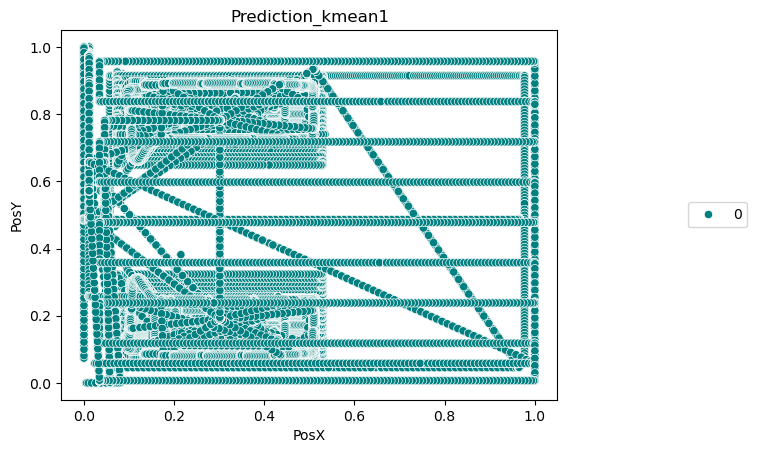

2
Prediction_kmean2


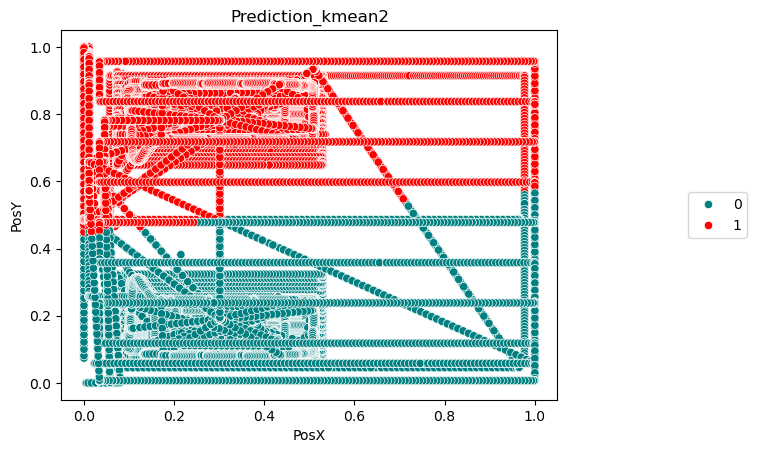

3
Prediction_kmean3


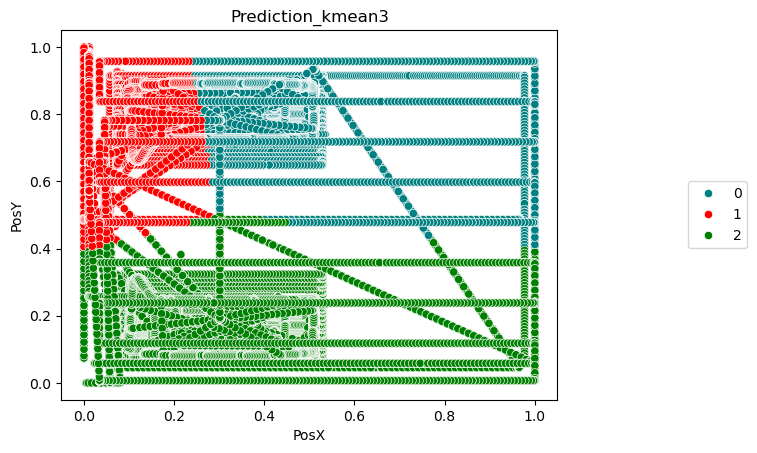

4
Prediction_kmean4


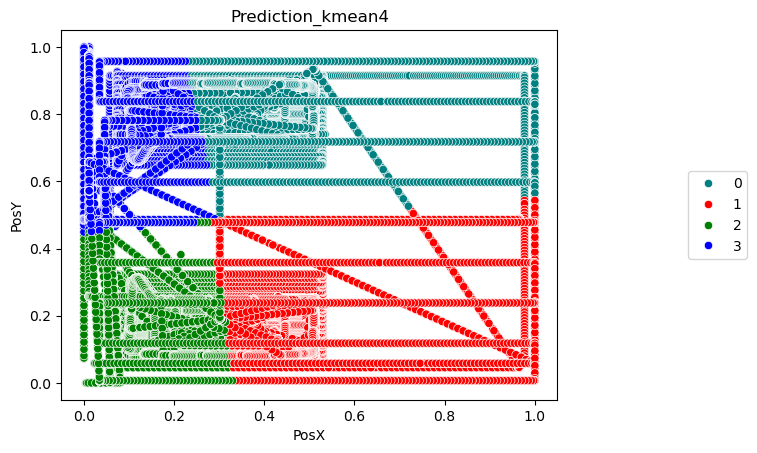

5
Prediction_kmean5


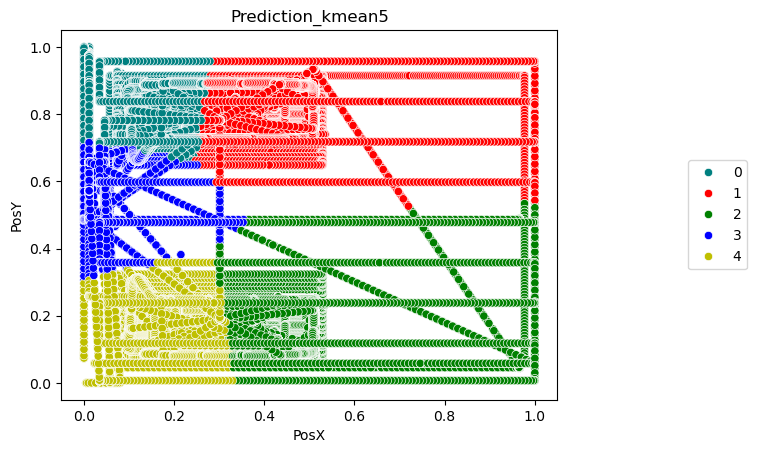

6
Prediction_kmean6


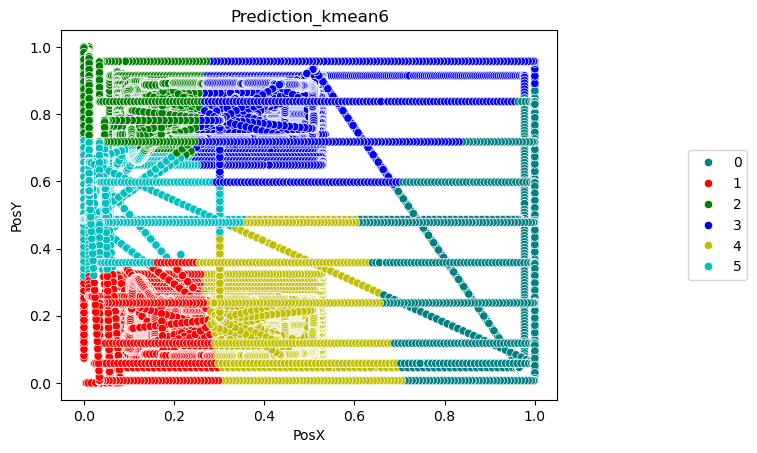

7
Prediction_kmean7


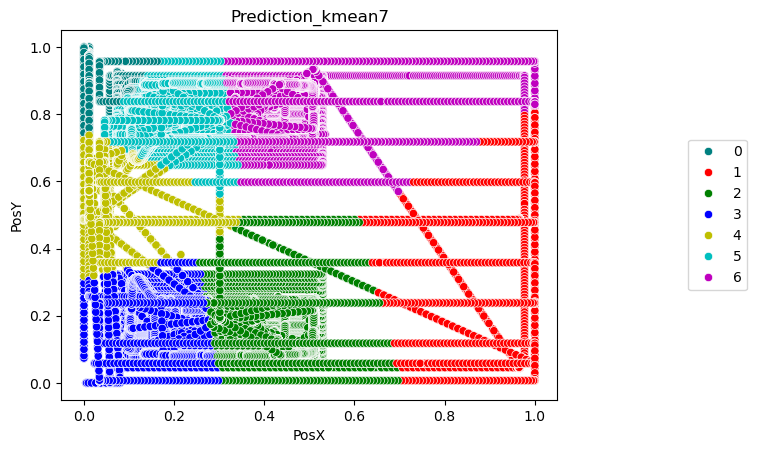

8
Prediction_kmean8


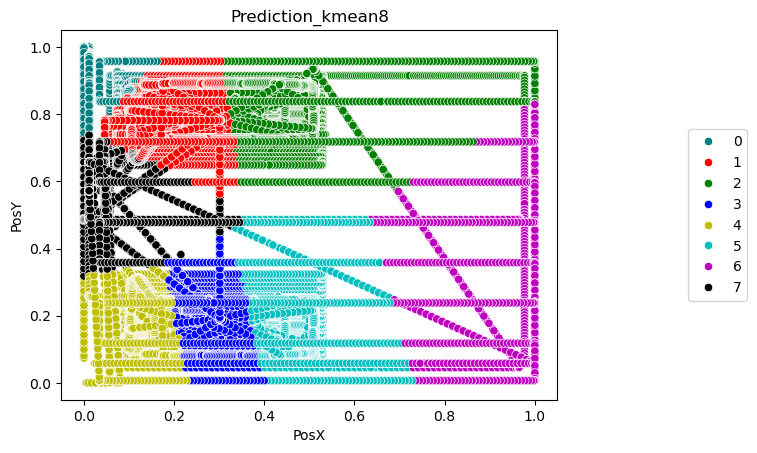

9
Prediction_kmean9


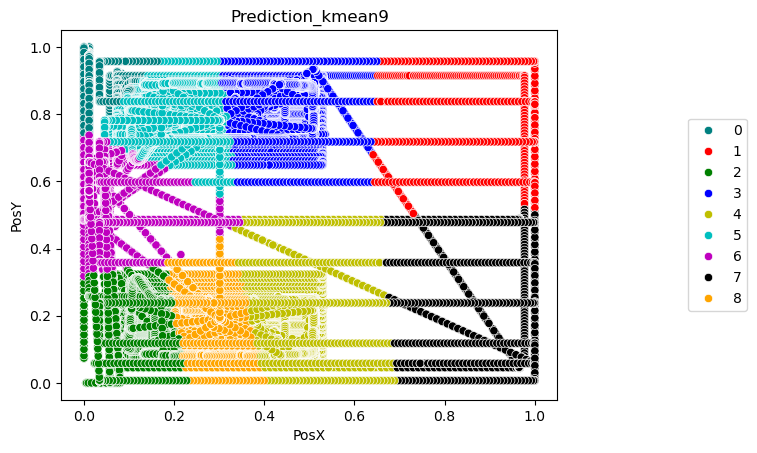

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


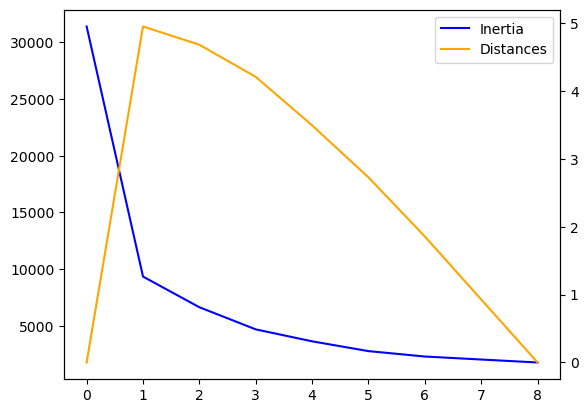

The maximimal increase is obtained for 2 clusters


In [15]:
My_function_kmeans_elbow(9, Norm_32)

The Elbow analyse suggests that there are 2 different clusters, i.e. 2 different parts. Lets trys to apply the found clusters for program 35

### Application on Prog 35

In [16]:
kmeans = KMeans(n_clusters=2, max_iter=50,init='random')
kmeans.fit(Norm_32[Input_cols])  

KMeans(init='random', max_iter=50, n_clusters=2)

In [17]:
dp_35 = data_panda[data_panda['idProgP'] == 35]
nb_specimen=len(dp_35 )
print('There are '+ str(nb_specimen)+' records in this subset set')
Norm_35 = dp_35.reset_index()
#normalisation
Norm_35[Input_cols]=(Norm_35[Input_cols]-Norm_35[Input_cols].min())/(Norm_35[Input_cols].max()-Norm_35[Input_cols].min())



There are 141115 records in this subset set


Kmeans learned on Prg32 applied on Prg35


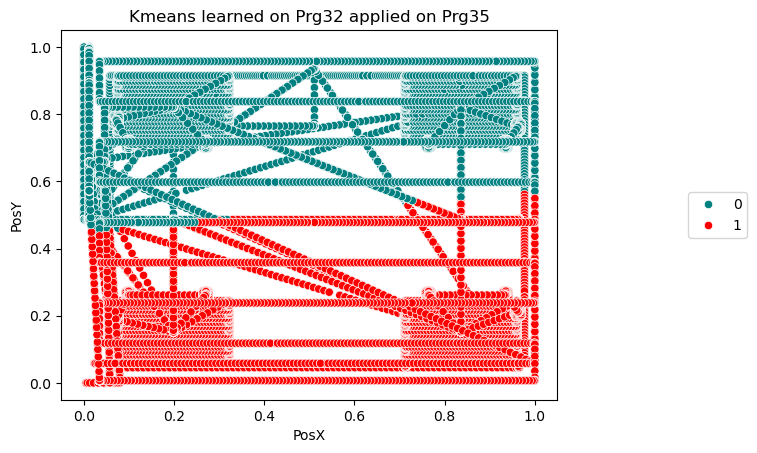

In [ ]:
#actual prediction on Prog 35
y_pred_kmean = kmeans.predict(Norm_35[Input_cols])
pred = pd.DataFrame(y_pred_kmean)
name='Kmeans learned on Prg32 applied on Prg35'
pred.columns = [name]
print(name)
Norm_35 = pd.concat([Norm_35,pred], axis = 1)
#print(Norm_32)
sns.scatterplot(x='PosX', y='PosY', hue=name, palette=color_dict_cluster, data=Norm_35)
plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
plt.title(name) 
plt.show()     

The clustering cannot be used per se, yet the method can be replicated

In [17]:
#My_function_kmeans_elbow(9, Norm_35)

## GMM



In [19]:
#funtion to draw mutlivariate Gaussian
def multivariate_gaussian(pos, mu, Sigma):
    """Return the multivariate Gaussian distribution on array pos.

    pos is an array constructed by packing the meshed arrays of variables
    x_1, x_2, x_3, ..., x_k into its _last_ dimension.

    """

    n = mu.shape[0]
    Sigma_det = np.linalg.det(Sigma)
    Sigma_inv = np.linalg.inv(Sigma)
    N = np.sqrt((2*np.pi)**n * Sigma_det)
    # This einsum call calculates (x-mu)T.Sigma-1.(x-mu) in a vectorized
    # way across all the input variables.
    fac = np.einsum('...k,kl,...l->...', pos-mu, Sigma_inv, pos-mu)

    return np.exp(-fac / 2) / N

In [20]:
from sklearn import mixture
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture


In [21]:
nb_GMM=3
gmm = GaussianMixture(n_components=nb_GMM)
#learn
gmm.fit(Norm_32[Input_cols])
m=gmm.means_
cov=gmm.covariances_
w=gmm.weights_

In [22]:
#Apply
name='GMM_'+str(nb_GMM)      
y_pred_GMM = gmm.predict(Norm_32[Input_cols])
#We store the results in a dataframe
pred = pd.DataFrame(y_pred_GMM)    
pred.columns = [name]
Norm_32 = pd.concat([Norm_32,pred], axis = 1)


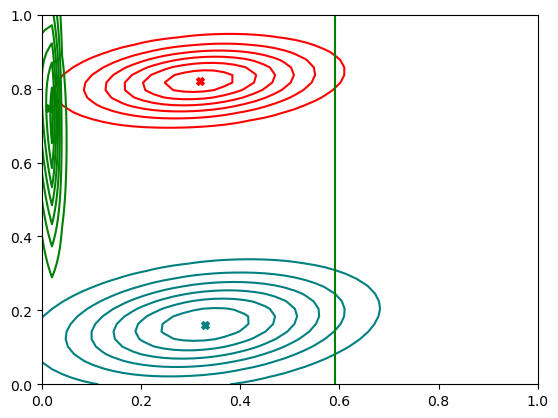

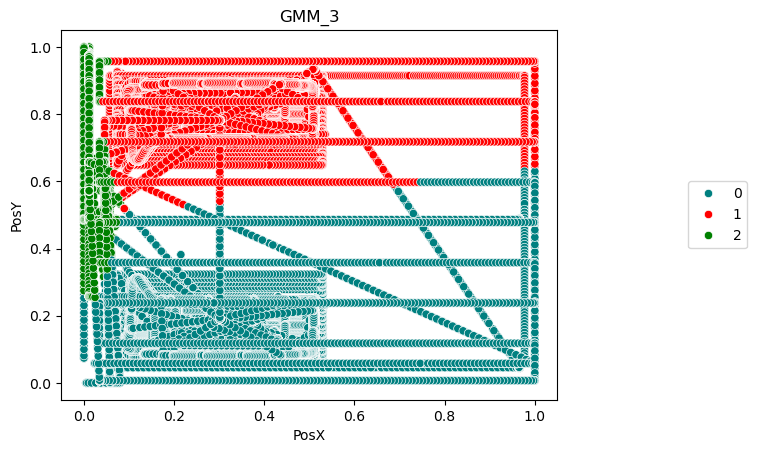

In [23]:
# Plotting
x = np.linspace(0, 1)
y = np.linspace(0, 1)
X,Y = np.meshgrid(x,y)
# Pack X and Y into a single 3-dimensional array
pos = np.empty(X.shape + (2,))
pos[:, :, 0] = X
pos[:, :, 1] = Y
for i in range (nb_GMM):
    Z = multivariate_gaussian(pos, m[i], cov[i])
    plt.contour(X,Y,Z,colors=color_dict_cluster[i])
    plt.scatter(m[i,0],m[i,1],marker='X',c=color_dict_cluster[i],s=30)    
#plt.scatter(Norm_32['PosX'],Norm_32['PosY'],marker='o',c='b',s=2)    
plt.show()

sns.scatterplot(x='PosX', y='PosY', hue=name, palette=color_dict_cluster, data=Norm_32)
plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
plt.title(name) 
plt.show() 


In [24]:
def My_function_GMM_BIC(max_clusters,df):# Finding the Optimal Number of Clusters - Plotting BIC Curve
#needed structures
    norm = np.linalg.norm
#arrays
    bic_scores= []
    distances= []
    range_n_clusters = np.arange(1, (max_clusters+1), 1)
#integers
    bic_score=0
    best=0
    #print(range_n_clusters)
    for num_clusters in range_n_clusters:
        print(num_clusters)     
        name='Prediction_GMM'+ str(num_clusters)
        gmm = GaussianMixture(n_components=num_clusters)        
        fitted_model=gmm.fit(df[Input_cols])            
        #actual prediction
        y_pred_kmean = gmm.predict(df[Input_cols])
        #We store the results in a dataframe
        pred = pd.DataFrame(y_pred_kmean)    
        pred.columns = [name]
        print(name)
        df = pd.concat([df,pred], axis = 1)
    #print(df prediction)
        sns.scatterplot(x='PosX', y='PosY', hue=name, palette=color_dict_cluster, data=df)
        plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
        plt.title(name) 
        plt.show()     
        # BIC analysis  
        bic_score = -fitted_model.bic(df[Input_cols])
        bic_scores.append(bic_score)
    p1 = np.array([1,bic_scores[0]])    
    p2 = np.array([max_clusters,bic_scores[max_clusters-1]])    
    for i in range(0,max_clusters):        
        p = np.array([i+1,bic_scores[i]])        
        distances.append(norm(np.cross(p2-p1, p1-p))/norm(p2-p1))    
    size=len(bic_scores)+1
    ax1 = plt.subplot()
    l1, = ax1.plot(bic_scores, color='blue')
    ax2 = ax1.twinx()
    l2, = ax2.plot(distances, color='orange')
    plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
    plt.legend([l1, l2], ["BIC", "Distances"])
    plt.show()
    #identification of the Elbow
    best=distances.index(max(distances))+1 
    print('The maximimal increase is obtained for '+ str(best)+' clusters' )


1
Prediction_GMM1


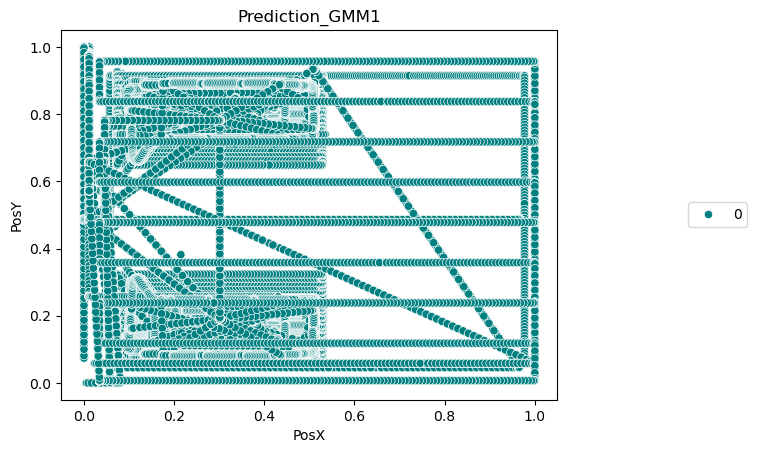

2
Prediction_GMM2


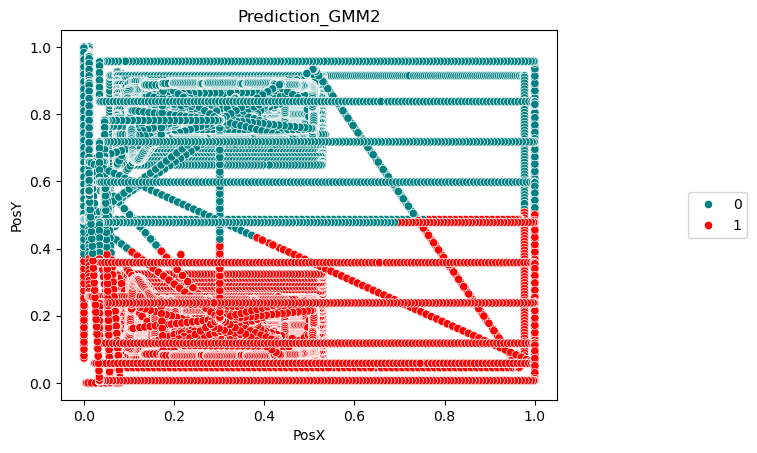

3
Prediction_GMM3


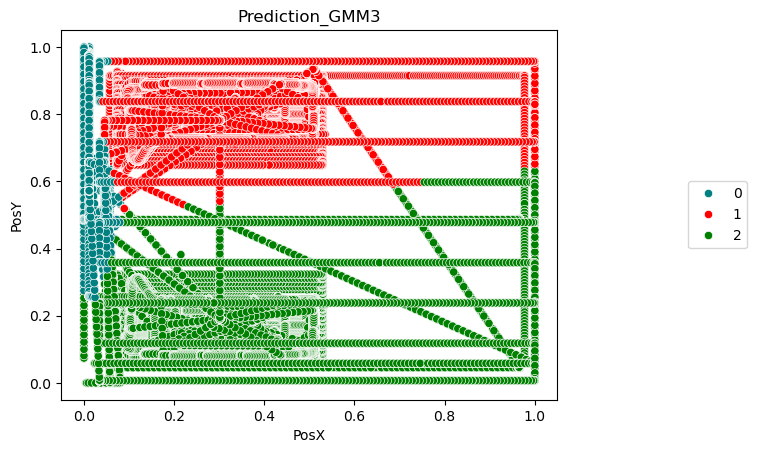

4
Prediction_GMM4


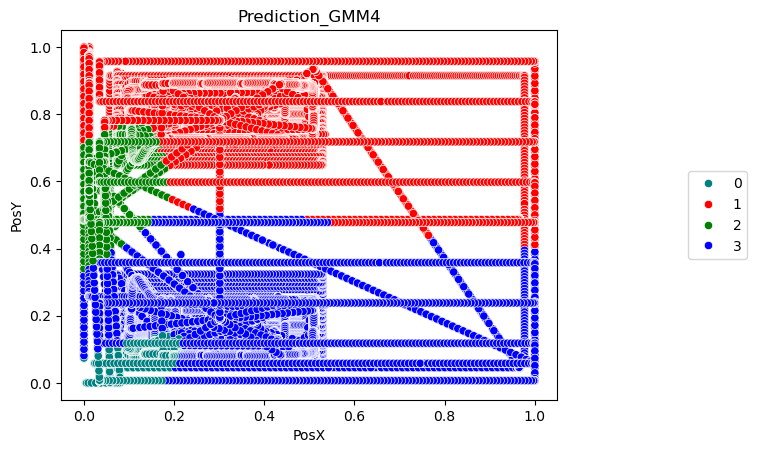

5
Prediction_GMM5


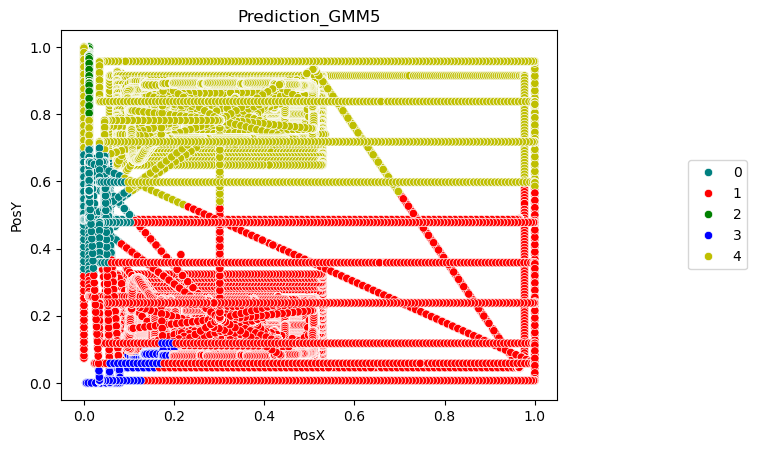

6
Prediction_GMM6


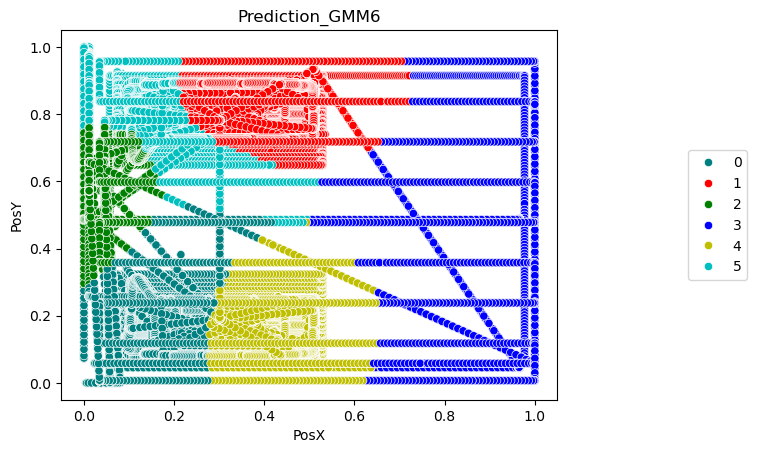

7
Prediction_GMM7


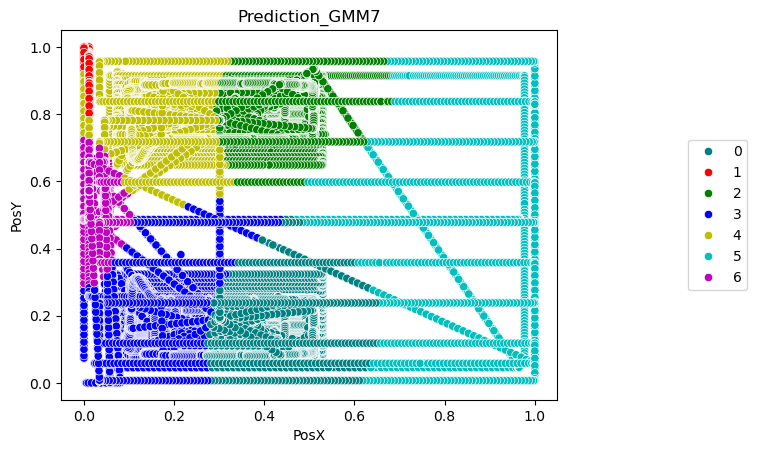

8
Prediction_GMM8


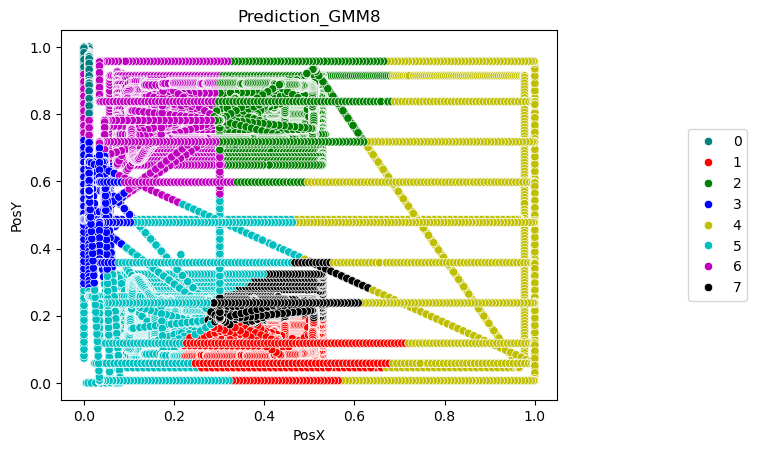

9
Prediction_GMM9


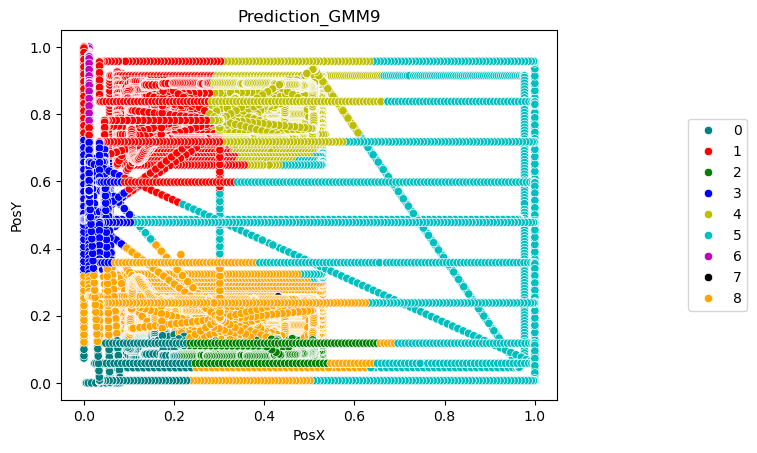

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


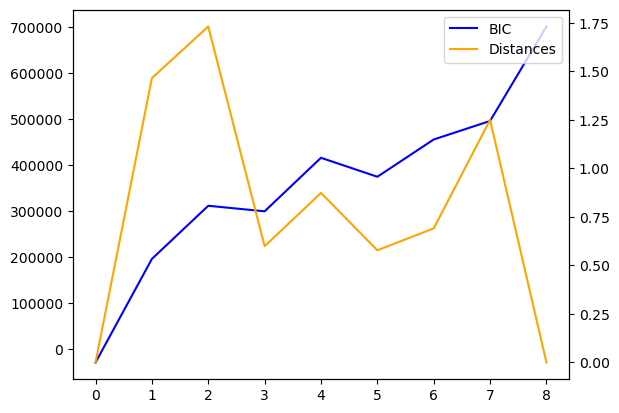

The maximimal increase is obtained for 3 clusters


In [25]:
My_function_GMM_BIC(9,Norm_32)

## Hierarchical Ascendant Classification 


# Objective 2: productivity

In [26]:
#selection of the relevant Input data
Input_cols2=['SpeedX','SpeedA','Vf ','N','P']
#normalisation
Norm_32[Input_cols2]=(Norm_32[Input_cols2]-Norm_32[Input_cols2].min())/(Norm_32[Input_cols2].max()-Norm_32[Input_cols2].min())
#print(Norm_32[Input_cols])

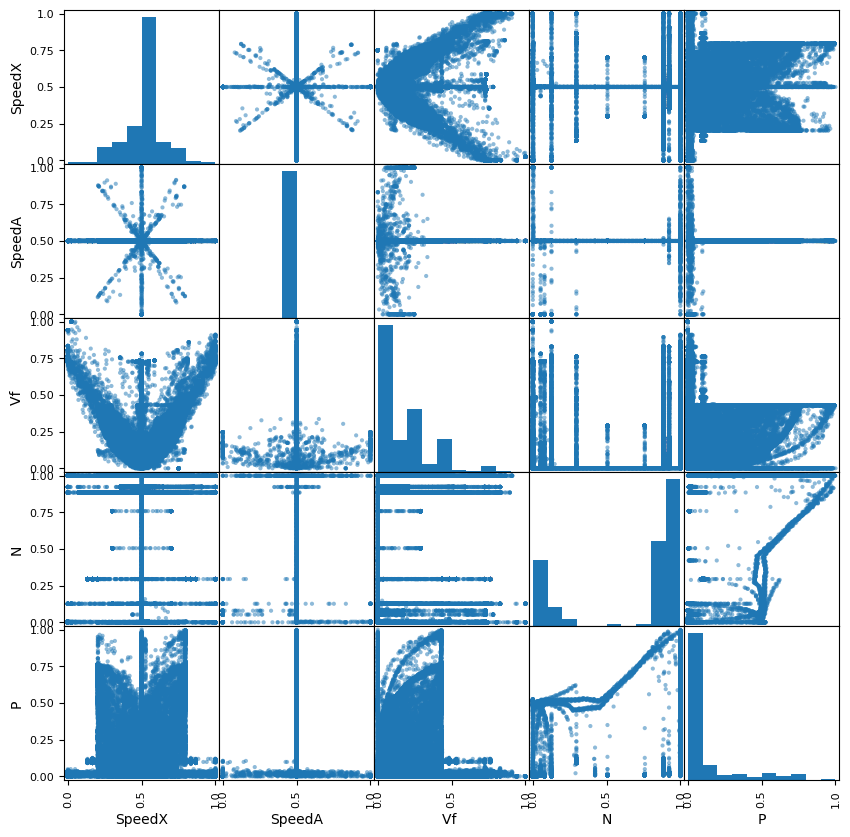

In [27]:
scatter_matrix(Norm_32[Input_cols2], figsize=(10, 10), diagonal='hist');

## Unsupervised machine learning with Kmeans


In [28]:
kmeans = KMeans(n_clusters=2, max_iter=50,init='random')
name='Kmean_MachiningOrNot'
Kmeans_machining=kmeans.fit(Norm_32[Input_cols2])  
y_pred_kmean = kmeans.predict(Norm_32[Input_cols2])
#We store the K-means results in a dataframe
pred = pd.DataFrame(y_pred_kmean)    
pred.columns = [name]
print(name)
Norm_32 = pd.concat([Norm_32,pred], axis = 1)


Kmean_MachiningOrNot


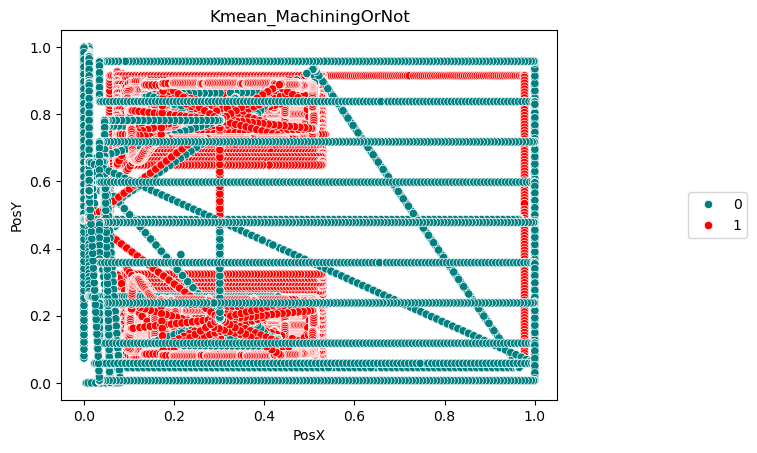

In [29]:
sns.scatterplot(x='PosX', y='PosY', hue=name, palette=color_dict_cluster, data=Norm_32)
plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
plt.title(name) 
plt.show()     
        

## Unsupervised machine learning with GMM

In [30]:
gmm = GaussianMixture(n_components=2)  
name='GMM_MachiningOrNot'      
fitted_model_machining=gmm.fit(Norm_32[Input_cols2])            
#actual prediction
y_pred_GMM = gmm.predict(Norm_32[Input_cols2])
#We store the results in a dataframe
pred = pd.DataFrame(y_pred_GMM)    
pred.columns = [name]
print(name)
Norm_32 = pd.concat([Norm_32,pred], axis = 1)

GMM_MachiningOrNot


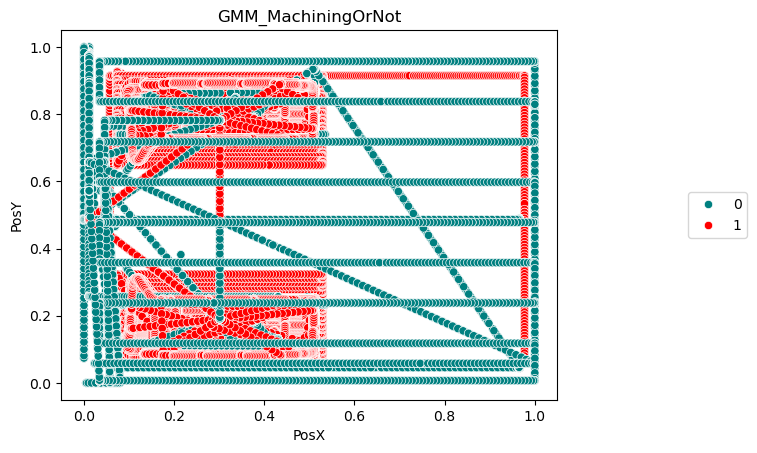

In [31]:
sns.scatterplot(x='PosX', y='PosY', hue=name, palette=color_dict_cluster, data=Norm_32)
plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
plt.title(name) 
plt.show()

## Knowledge integration

In [32]:
#creation of the column
Norm_32['KI'] = 0

In [33]:
#if Vf<0,5 and P!=0 then Machining
for i in range(len(Norm_32)):
    if (Norm_32['Vf '].values[i])<0.5 and (Norm_32['P'].values[i])>0:
        Norm_32['KI'].values[i] = 1



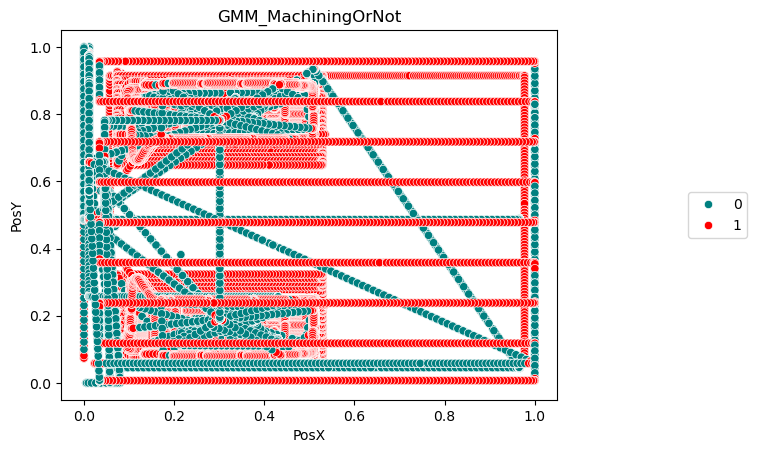

In [34]:
sns.scatterplot(x='PosX', y='PosY', hue='KI', palette=color_dict_cluster, data=Norm_32)
plt.legend(loc='center left', bbox_to_anchor=(1.25, 0.5), ncol=1)
plt.title(name) 
plt.show()

## Evaluation
We can apply the model learned on Prog 32 on all the records
### Application on the whole data base

In [35]:
#normalisation
Norm_data_panda=data_panda.copy(deep=False)
Norm_data_panda[Input_cols2]=(data_panda[Input_cols2]-data_panda[Input_cols2].min())/(data_panda[Input_cols2].max()-data_panda[Input_cols2].min())
#Kmeans
name='Kmean_MachiningOrNot'
y_pred_kmean = kmeans.predict(Norm_data_panda[Input_cols2])
#We store the K-means results in a dataframe
pred = pd.DataFrame(y_pred_kmean)    
pred.columns = [name]
print(name)
Norm_data_panda= pd.concat([Norm_data_panda,pred], axis = 1)
#GMM
name='GMM_MachiningOrNot'      
#actual prediction
y_pred_GMM = gmm.predict(data_panda[Input_cols2])
#We store the results in a dataframe
pred = pd.DataFrame(y_pred_GMM)    
pred.columns = [name]
print(name)
Norm_data_panda= pd.concat([Norm_data_panda,pred], axis = 1)
#KI
#creation of the column
Norm_data_panda['KI'] = 0

Kmean_MachiningOrNot
GMM_MachiningOrNot


In [36]:
for i in range(len(Norm_data_panda)):
    if (Norm_data_panda['Vf '].values[i])<0.5 and (Norm_data_panda['P'].values[i])>0:
        Norm_data_panda['KI'].values[i] = 1

In [37]:
#import of the observations and creation of panda object
Label_panda = pd.read_csv('idx_usi.csv')
print(Label_panda.keys())

Index(['Observations'], dtype='object')


In [38]:
if (len(data_panda)==len(Label_panda)):
    print('There are as many labels as there are records')
else :    
    print('The numbers of labels do not match the number of records')

There are as many labels as there are records


In [39]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [40]:
methods=[]
Accuracy=[]

In [41]:
M_KI_perf=confusion_matrix(Label_panda['Observations'],Norm_data_panda['KI'])
print('For knowledge integration, the confusion matrix is as follow (rows are observations, colums predictions)')
print (M_KI_perf)
Dict_KI=classification_report(Label_panda['Observations'],Norm_data_panda['KI'], output_dict=True)
print('The Knowledge integration gives an accuracy of ')
print(Dict_KI['accuracy'])
methods.append('KI')
Accuracy.append(Dict_KI['accuracy'])

For knowledge integration, the confusion matrix is as follow (rows are observations, colums predictions)
[[213192  29838]
 [ 15599 603945]]
The Knowledge integration gives an accuracy of 
0.9473239397431409


In [42]:
M_Kmean_perf=confusion_matrix(Label_panda['Observations'],Norm_data_panda['Kmean_MachiningOrNot'])
print('For Kmean, the confusion matrix is as follow (rows are observations, colums predictions)')
print (M_Kmean_perf)
Dict_Kmean=classification_report(Label_panda['Observations'],Norm_data_panda['Kmean_MachiningOrNot'], output_dict=True)
print('Kmean gives an accuracy of ')
print(Dict_Kmean['accuracy'])
methods.append('Kmean')
Accuracy.append(Dict_Kmean['accuracy'])

For Kmean, the confusion matrix is as follow (rows are observations, colums predictions)
[[241973   1057]
 [ 15476 604068]]
Kmean gives an accuracy of 
0.9808329488252602


In [43]:
M_Kmean_perf=confusion_matrix(Label_panda['Observations'],Norm_data_panda['GMM_MachiningOrNot'])
print('For GMM, the confusion matrix is as follow (rows are observations, colums predictions)')
print (M_Kmean_perf)
Dict_Kmean=classification_report(Label_panda['Observations'],Norm_data_panda['GMM_MachiningOrNot'], output_dict=True)
print('GMM gives an accuracy of ')
print(Dict_Kmean['accuracy'])
methods.append('GMM')
Accuracy.append(Dict_Kmean['accuracy'])

For GMM, the confusion matrix is as follow (rows are observations, colums predictions)
[[237824   5206]
 [619543      1]]
GMM gives an accuracy of 
0.2757154748462161


Please note that for K_means and GMM, there is no guaranties that the cluster corresponding to 'not machining' will be numbered as 0. In order to overcome this you should use the function stored in the Matching_cluster.ipynb file

In [44]:
import import_ipynb
import Matching_cluster

In [49]:
acc,y_pred,dict_map_cluster_kmean =Matching_cluster.remap_labels(Norm_data_panda['Kmean_MachiningOrNot'],Label_panda['Observations'])
print(dict_map_cluster_kmean)
#We store the K-means results in a dataframe
pred_1 = pd.DataFrame(y_pred)
pred_1.columns = ['Machining_Prediction_kmean_mapped']
#we merge this dataframe 
Norm_data_panda= pd.concat([Norm_data_panda,pred_1], axis = 1)
acc,y_pred,dict_map_cluster_gmm =Matching_cluster.remap_labels(Norm_data_panda['GMM_MachiningOrNot'],Label_panda['Observations'])
print(dict_map_cluster_gmm)
#We store the K-means results in a dataframe
pred_1 = pd.DataFrame(y_pred)
pred_1.columns = ['Machining_Prediction_gmm_mapped']
#we merge this dataframe 
Norm_data_panda= pd.concat([Norm_data_panda,pred_1], axis = 1)

{0: 0, 1: 1}
{0: 1, 1: 0}


In [50]:
M_Kmean_perf=confusion_matrix(Label_panda['Observations'],Norm_data_panda['Machining_Prediction_kmean_mapped'])
print('For Kmean, the confusion matrix is as follow (rows are observations, colums predictions)')
print (M_Kmean_perf)
Dict_Kmean=classification_report(Label_panda['Observations'],Norm_data_panda['Machining_Prediction_kmean_mapped'], output_dict=True)
print('Kmean gives an accuracy of ')
print(Dict_Kmean['accuracy'])
methods.append('Kmean_mapped')
Accuracy.append(Dict_Kmean['accuracy'])

For Kmean, the confusion matrix is as follow (rows are observations, colums predictions)
[[241973   1057]
 [ 15476 604068]]
Kmean gives an accuracy of 
0.9808329488252602


In [51]:
M_GMM_perf=confusion_matrix(Label_panda['Observations'],Norm_data_panda['Machining_Prediction_gmm_mapped'])
print('For GMM, the confusion matrix is as follow (rows are observations, colums predictions)')
print (M_GMM_perf)
Dict_GMM=classification_report(Label_panda['Observations'],Norm_data_panda['Machining_Prediction_gmm_mapped'], output_dict=True)
print('GMM gives an accuracy of ')
print(Dict_GMM['accuracy'])
methods.append('GMM_mapped')
Accuracy.append(Dict_GMM['accuracy'])

For GMM, the confusion matrix is as follow (rows are observations, colums predictions)
[[  5206 237824]
 [     1 619543]]
GMM gives an accuracy of 
0.7242845251537839


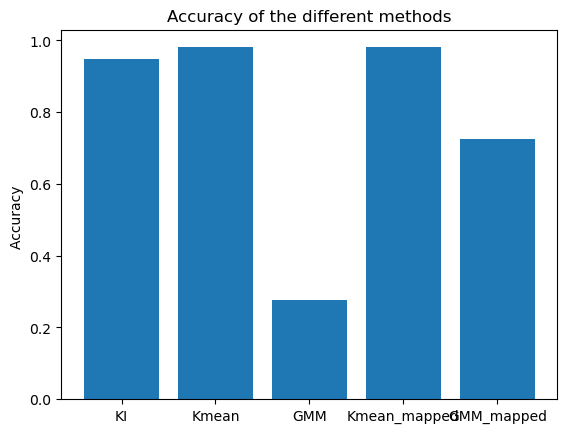

In [52]:

fig, ax = plt.subplots()
ax.bar(methods, Accuracy)
ax.set_ylabel('Accuracy ')
ax.set_title('Accuracy of the different methods')
plt.show()

# Objective 3: productivity

## Global OEE

In [53]:
OEE=Norm_data_panda['Machining_Prediction_kmean_mapped'].value_counts()[1]/len(Norm_data_panda)
print(OEE)

0.7015340133136403


##  OEE per program

In [54]:
# list of values of 'idProgP' column
Prog_list = Norm_data_panda['idProgP'].unique()
print(Prog_list)

[31  3 32 28 33  2 34 35 36]


In [55]:
OEE_prog=[]
Prog_name=[]
for prog in Prog_list :
    Prog_name.append(str(prog))
    OEE=len(Norm_data_panda[(Norm_data_panda['Machining_Prediction_kmean_mapped']==1) & 
             (Norm_data_panda['idProgP']==prog)])/len(Norm_data_panda[(Norm_data_panda['idProgP']==prog)])
    
    OEE_prog.append(OEE)
   

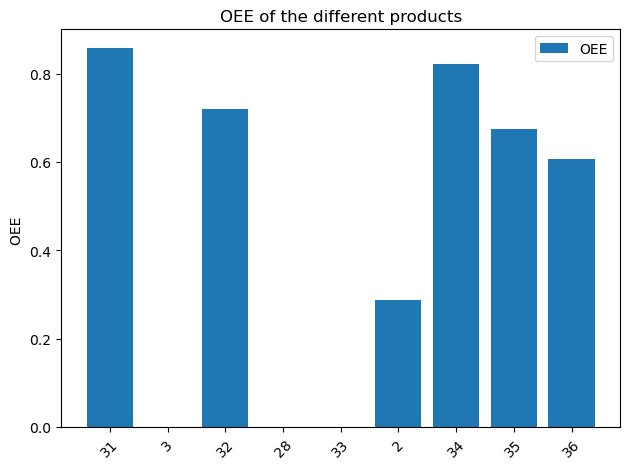

In [64]:
fig, ax = plt.subplots()
ax.bar(Prog_name, OEE_prog, label='OEE')
ax.set_ylabel('OEE ')
ax.set_title('OEE of the different products')
ax.legend(loc='upper right')  # legend placed on the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## OEE per tool

In [56]:
# list of values of 'idProgP' column
Tool_list = Norm_data_panda['idTool'].unique()
print(Tool_list)

[ 0  1  2  3  5  7  8 11 36 25 22 37 27 38 39 40 41 19 17 26 42  9]


In [57]:
OEE_tool=[]
Tool_name=[]
for tool in Tool_list :
    Tool_name.append(str(tool))
    OEE=len(Norm_data_panda[(Norm_data_panda['Machining_Prediction_kmean_mapped']==1) & 
             (Norm_data_panda['idTool']==tool)])/len(Norm_data_panda[(Norm_data_panda['idTool']==tool)])
    
    OEE_tool.append(OEE)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


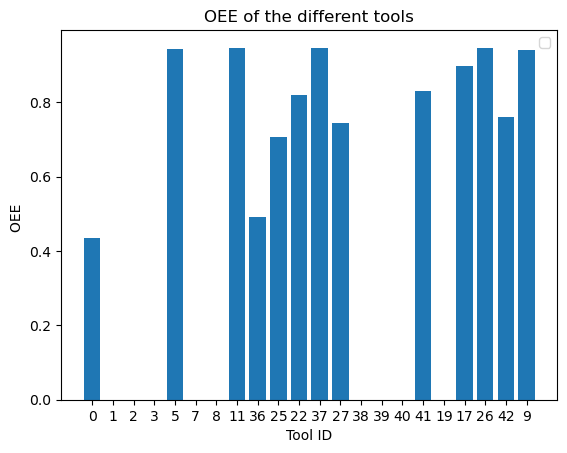

In [63]:
plt.bar(Tool_name, OEE_tool)
plt.ylabel('OEE ')
plt.xlabel('Tool ID')
plt.title('OEE of the different tools')
plt.legend()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=4df2295a-282c-4988-b813-1c769431c8cd' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>